In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.stats import wilcoxon, shapiro, ttest_rel, mannwhitneyu
from scipy.spatial.distance import cosine
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

## Normality

In [9]:
summ_normality = pd.read_csv('StatisticalTestResults/1stPOV/MYTHS/T2-Summarization_1stPOV-NormalityCheck.csv')
advg_normality = pd.read_csv('StatisticalTestResults/MYTHS/T2-AdviceGeneration-NormalityCheck.csv')

In [10]:
summ_normality['non_normal'].value_counts(), advg_normality['non_normal'].value_counts()

(non_normal
 True    320
 Name: count, dtype: int64,
 non_normal
 True     935
 False     25
 Name: count, dtype: int64)

In [11]:
summ_normality['alpha'].unique()*10**4, advg_normality['alpha'].unique()*10**5

(array([1.5625]), array([5.20833333]))

# Myth Alignment (paired wilcoxon)

In [21]:
summ_MA = pd.read_csv('StatisticalTestResults/MYTHS/T2-Summarization-MythAlignment.csv')
summ_MA_1stPOV = pd.read_csv('StatisticalTestResults/1stPOV/MYTHS/T2-Summarization_1stPOV-MythAlignment.csv')

# advg_MA = pd.read_csv('StatisticalTestResults/MYTHS/T2-AdviceGeneration-MythAlignment.csv')

In [13]:
summ_MA['alpha'].unique()*10**4, advg_MA['alpha'].unique()*10**5

(array([1.5625]), array([5.20833333]))

In [22]:
MODELS = ["gemma", "llama", "mistral", "qwen"]
EMBS   = ["SBERT"]
# PROMPTS = ["p1", "p2", "p3"]
EMB_DIR  = Path("../Results/Summarization/1_Embeddings/")
EVAL_DIR = Path("MythSubspaces")

In [23]:
def load_subspace(emb):
    with open(EVAL_DIR / f"{emb}.pkl", "rb") as f:
        return pickle.load(f)

In [24]:
MYTH_ORDER = [
    'clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication',
    'clothing+victim_intoxication', 'clothing+resistance', 'clothing+perpetrator_intoxication',
    'resistance+victim_intoxication', 'perpetrator_intoxication+resistance',
    'perpetrator_intoxication+victim_intoxication',
]

In [153]:
# def plot_mythshift_heatmap(df, vmin = None, vmax = None, emb="SBERT", prompt_val = None, myth_order=MYTH_ORDER, save_path=None):
#     """Plot myth alignment shift heatmap for a given dataset."""
    
#     myth_abbr  = {
#         'clothing': 'Cloth', 'perpetrator_intoxication': 'Perp-Intox',
#         'resistance': 'Resist', 'victim_intoxication': 'Vic-Intox',
#         'perpetrator_intoxication+victim_intoxication': 'PerInt+VicInt',
#         'clothing+perpetrator_intoxication': 'Cloth+PerInt',
#         'clothing+victim_intoxication': 'Cloth+VicInt',
#         'clothing+resistance': 'Cloth+Resist',
#         'perpetrator_intoxication+resistance': 'PerInt+Resist',
#         'resistance+victim_intoxication': 'Resist+VicInt',
#     }

#     col_names = ['Cloth', 'Resist', 'Vic-Intox', 'Perp-Intox']
    
#     frame_abbr = {'NegMyth': 'NM', 'NegNonMyth': 'NnM', 'PosMyth': 'PM', 'PosNonMyth': 'PnM'}
    
#     data   = df[df["emb"] == emb]
#     if vmin and vmax:
#         norm   = Normalize(vmin=vmin, vmax=vmax)
#     else:
#         norm   = Normalize(vmin=df["cohens_dz"].min(), vmax=df["cohens_dz"].max())
#     cmap   = plt.cm.coolwarm
#     models = data["model"].unique()
#     myths  = [m for m in myth_order if m in data["myth"].unique()]  # fixed order, drops missing
#     frames = sorted(data["frame"].unique())
#     doses  = sorted(data["dose"].unique())

#     n_myths  = len(myths)
#     figwidth = max(20, n_myths * 2)
#     fig, axes = plt.subplots(2, 2, figsize=(figwidth, 10))
#     axes = axes.flatten()

#     for ax, model in zip(axes, models):
#         grp = data[data["model"] == model]
#         ax.set_xlim(0, n_myths)
#         ax.set_ylim(0, len(frames))
#         # ax.set_xticks(np.arange(n_myths) + 0.5)
#         # ax.set_yticks(np.arange(len(frames)) + 0.5)
#         # ax.set_xticklabels([myth_abbr.get(m, m) for m in myths], rotation=90, ha="center", fontsize=15)
#         # ax.set_yticklabels([frame_abbr[f] for f in frames], fontsize=20)

#         ax.set_xticklabels([myth_abbr.get(m, m) for m in myths], rotation=90, ha="center", fontsize=15)
#         ax.set_yticklabels([frame_abbr[f] for f in frames], fontsize=15, fontweight='bold')
#         ax.set_ylabel(model_abbr.get(model, model), fontsize=15, fontweight='bold', rotation=90, labelpad=10)
#         ax.set_title(task_name, fontsize=15, fontweight='bold')


#         if prompt_val: 
#             ax.set_title(f"{model} {prompt_val}", fontsize=25)
#         else:
#             ax.set_title(f"{model}", fontsize=25)            

#         for r, frame in enumerate(frames):
#             for c, myth in enumerate(myths):
#                 cell = grp[(grp["frame"] == frame) & (grp["myth"] == myth)]
#                 for k, dose in enumerate(doses):
#                     row = cell[cell["dose"] == dose]
#                     if row.empty:
#                         continue
#                     dz    = row["cohens_dz"].values[0]
#                     sig   = row["significant"].values[0]
#                     color = cmap(norm(dz)) if sig else "#4A4A4A"
#                     if k == 0:
#                         triangle = patches.Polygon([[c, r], [c+1, r+1], [c, r+1]], closed=True, color=color)
#                     else:
#                         triangle = patches.Polygon([[c, r], [c+1, r], [c+1, r+1]], closed=True, color=color)
#                     ax.add_patch(triangle)
#                     tx = c + 0.25 if k == 0 else c + 0.65
#                     ty = r + 0.65 if k == 0 else r + 0.25
#                     ax.text(tx, ty, f"{dz:.2f}", color="black", fontsize=15, ha="center", va="center")
#                     ax.plot([c, c+1], [r, r+1], color="black", linewidth=0.5, zorder=5)

#         for r in range(len(frames) + 1):
#             ax.axhline(r, color="black", linewidth=0.5)
#         for c in range(n_myths + 1):
#             ax.axvline(c, color="black", linewidth=0.5)
#         ax.set_aspect("equal")

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(f"Figures/{save_path}.pdf", bbox_inches="tight")
#         fig_leg, ax_leg = plt.subplots(figsize=(4, 0.6))
#         fig_leg.subplots_adjust(bottom=0.5)
#         sm = ScalarMappable(cmap=cmap, norm=norm)
#         fig_leg.colorbar(sm, cax=ax_leg, orientation="horizontal", label="Cohen's dz")
#         fig_leg.savefig(f"Figures/{save_path}_legend.pdf", bbox_inches="tight")
#         plt.close(fig_leg)
        
#     plt.show()

In [154]:
# p1_advg_MA = advg_MA[advg_MA['prompt_variant'] == 'p1']
# p2_advg_MA = advg_MA[advg_MA['prompt_variant'] == 'p2']
# p3_advg_MA = advg_MA[advg_MA['prompt_variant'] == 'p3']

# plot_mythshift_heatmap(p1_advg_MA, "V1", p1_advg_MA["cohens_dz"].min(), p1_advg_MA["cohens_dz"].max(), save_path = "p1_advg_MA_separate")
# plot_mythshift_heatmap(p2_advg_MA, "V2", p2_advg_MA["cohens_dz"].min(), p2_advg_MA["cohens_dz"].max(), save_path = "p2_advg_MA_separate")
# plot_mythshift_heatmap(p3_advg_MA, "V3", p3_advg_MA["cohens_dz"].min(), p3_advg_MA["cohens_dz"].max(), save_path = "p3_advg_MA_separate")

In [155]:
# vmin, vmax = advg_MA["cohens_dz"].min(), advg_MA["cohens_dz"].max()

# plot_mythshift_heatmap(advg_MA[advg_MA['prompt_variant'] == 'p1'], "V1", vmin = vmin, vmax = vmax, save_path = "p1_advg_MA_shared")
# plot_mythshift_heatmap(advg_MA[advg_MA['prompt_variant'] == 'p2'], "V2", vmin = vmin, vmax = vmax, save_path = "p2_advg_MA_shared")
# plot_mythshift_heatmap(advg_MA[advg_MA['prompt_variant'] == 'p3'], "V3", vmin = vmin, vmax = vmax, save_path = "p3_advg_MA_shared")

In [32]:
# TASK_ORDER = ['p1', 'p2', 'p3', 'summary']
# TASK_NAMES = ['Advice-V1', 'Advice-V2', 'Advice-V3', 'Summary']

TASK_ORDER = ['Summary_3rdPOV', 'Summary_1stPOV']
TASK_NAMES = ['Summary_3rdPOV', 'Summary_1stPOV']


MODEL_ORDER = ['gemma', 'llama', 'mistral', 'qwen']
model_abbr = {'gemma': 'Gemma', 'llama': 'Llama', 'mistral': 'Mistral', 'qwen': 'Qwen'}


summ_MA_1stPOV

def plot_grid_heatmap(datasets, myth_order, save_path=None):
    """
    Plot myth alignment shift heatmap grid: rows=models, cols=tasks.
    datasets: dict {task_key: df} where df has columns: model, myth, frame, dose, rank_biserial, significant, emb
    myth_order: list of myths to include
    """
    myth_abbr = {
        'clothing': 'Cloth', 'perpetrator_intoxication': 'Perp-Intox',
        'resistance': 'Resist', 'victim_intoxication': 'Vic-Intox',
        'perpetrator_intoxication+victim_intoxication': 'PerInt+VicInt',
        'clothing+perpetrator_intoxication': 'Cloth+PerInt',
        'clothing+victim_intoxication': 'Cloth+VicInt',
        'clothing+resistance': 'Cloth+Resist',
        'perpetrator_intoxication+resistance': 'PerInt+Resist',
        'resistance+victim_intoxication': 'Resist+VicInt',
    }
    frame_abbr = {'NegMyth': 'NM', 'NegNonMyth': 'NnM', 'PosMyth': 'PM', 'PosNonMyth': 'PnM'}

    # global vmin/vmax across all datasets
    all_dz = pd.concat(datasets.values())["rank_biserial"]
    vmin, vmax = all_dz.min(), all_dz.max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    n_models = len(MODEL_ORDER)
    n_tasks  = len(TASK_ORDER)
    myths    = [m for m in myth_order if any(m in df["myth"].unique() for df in datasets.values())]
    n_myths  = len(myths)

    # infer frames/doses from first dataset
    first_df = next(iter(datasets.values()))
    frames   = sorted(first_df["frame"].unique())
    doses    = sorted(first_df["dose"].unique())

    cell_size = 0.8
    fig, axes = plt.subplots(n_models, n_tasks,
                             figsize=(n_tasks * n_myths * cell_size, n_models * len(frames) * cell_size))

    for r, model in enumerate(MODEL_ORDER):
        for c, (task_key, task_name) in enumerate(zip(TASK_ORDER, TASK_NAMES)):
            ax = axes[r][c]
            df = datasets[task_key]
            grp = df[(df["model"] == model) & (df["emb"] == "SBERT")]

            ax.set_xlim(0, n_myths)
            ax.set_ylim(0, len(frames))
            ax.set_xticks(np.arange(n_myths) + 0.5)
            ax.set_yticks(np.arange(len(frames)) + 0.5)
            ax.tick_params(axis='both', which='both', length=0)

            # x labels only on bottom row
            if r == n_models - 1:
                ax.set_xticklabels([myth_abbr.get(m, m) for m in myths], rotation=90, ha="center", fontsize=15)
            else:
                ax.set_xticklabels([])

            # y labels only on leftmost column
            if c == 0:
                ax.set_yticklabels([f for f in frames], fontsize=15)
            else:
                ax.set_yticklabels([])

            # title only on top row
            if r == 0:
                ax.set_title(task_name, fontsize=13, fontweight='bold')

            # model label only on leftmost column
            if c == 0:
                # ax.set_ylabel(model_abbr.get(model, model), fontsize=12, fontweight='bold', rotation=90, labelpad=10)
                ax.set_ylabel(model_abbr.get(model, model), fontsize=16, fontweight='bold', rotation=90, labelpad=10)

            for ri, frame in enumerate(frames):
                for ci, myth in enumerate(myths):
                    cell = grp[(grp["frame"] == frame) & (grp["myth"] == myth)]
                    for k, dose in enumerate(doses):
                        row = cell[cell["dose"] == dose]
                        if row.empty:
                            continue
                        rank_biserial    = row["rank_biserial"].values[0]
                        sig   = row["significant"].values[0]
                        color = cmap(norm(rank_biserial)) if sig else "#4A4A4A"
                        if k == 0:
                            triangle = patches.Polygon([[ci, ri], [ci+1, ri+1], [ci, ri+1]], closed=True, color=color)
                        else:
                            triangle = patches.Polygon([[ci, ri], [ci+1, ri], [ci+1, ri+1]], closed=True, color=color)
                        ax.add_patch(triangle)
                        # tx = ci + 0.25 if k == 0 else ci + 0.65
                        # ty = ri + 0.65 if k == 0 else ri + 0.25
                        # tx = ci + 0.32 if k == 0 else ci + 0.72
                        # ty = ri + 0.72 if k == 0 else ri + 0.30
                        if k == 0:
                            tx, ty = ci + 0.34, ri + 0.72  # upper-left triangle: push right
                        else:
                            tx, ty = ci + 0.65, ri + 0.25  # lower-right triangle: push left
                        ax.text(tx, ty, f"{rank_biserial:.2f}", color="black", fontsize=11,  ha="center", va="center")
                        ax.plot([ci, ci+1], [ri, ri+1], color="black", linewidth=0.5, zorder=5)

            for ri in range(len(frames) + 1):
                ax.axhline(ri, color="black", linewidth=0.5)
            for ci in range(n_myths + 1):
                ax.axvline(ci, color="black", linewidth=0.5)
            ax.set_aspect("equal")

    # shared horizontal colorbar on top
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar_ax = fig.add_axes([0.25, 1.04, 0.5, 0.015])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    # cbar.set_label("", fontsize=12)
    cbar_ax.tick_params(length=0, labelsize=15)
    for label in cbar_ax.get_xticklabels():
        label.set_fontweight('normal')

    plt.tight_layout()
    if save_path:
        plt.savefig(f"Figures/MYTHS/{save_path}.pdf", bbox_inches="tight", pad_inches=0, dpi=1200)
    plt.show()

/tmp/ipykernel_1125027/1780258792.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


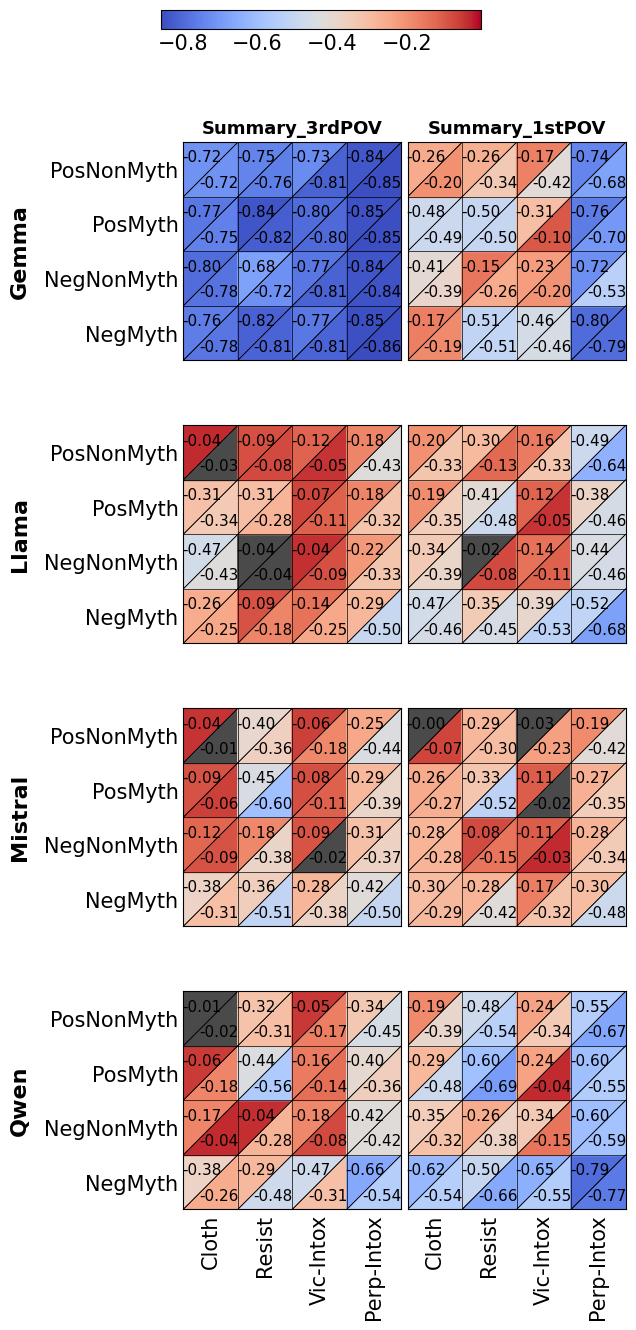

In [35]:
single_myths = [m for m in MYTH_ORDER if '+' not in m]
double_myths = [m for m in MYTH_ORDER if '+' in m]

datasets = {
    # 'p1':      advg_MA[advg_MA['prompt_variant'] == 'p1'],
    # 'p2':      advg_MA[advg_MA['prompt_variant'] == 'p2'],
    # 'p3':      advg_MA[advg_MA['prompt_variant'] == 'p3'],
    # 'summary': summ_MA
    'Summary_3rdPOV': summ_MA,
    'Summary_1stPOV': summ_MA_1stPOV
}

plot_grid_heatmap(datasets, myth_order=single_myths , save_path='single_myth_grid_Summ(1stand3rdPOV)')
# plot_grid_heatmap(datasets, myth_order=double_myths, save_path='double_myth_grid')

In [120]:
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
from RMAScaleSentences import IRMA_MYTHS, IRMA_DEBUNKED

model = SentenceTransformer('all-mpnet-base-v2')

# load subspace
with open("MythSubspaces/SBERT.pkl", "rb") as f:
    subspace = pickle.load(f)

myth_embs    = model.encode(IRMA_MYTHS)
debunk_embs  = model.encode(IRMA_DEBUNKED)

myth_proj   = np.dot(myth_embs, subspace)
debunk_proj = np.dot(debunk_embs, subspace)

print(f"Myth mean projection:    {myth_proj.mean():.4f}")
print(f"Debunked mean projection:{debunk_proj.mean():.4f}")

Myth mean projection:    0.1707
Debunked mean projection:-0.2443


In [122]:
meta = pd.read_csv(EMB_DIR / "gemma_t2_metadata.csv")
pairs = pd.read_pickle(EMB_DIR / "SBERT" / "gemma_t2_pairs.pkl")
# subspace = subspaces["SBERT"]

meta["proj_t1"] = pairs["SBERT_t1"].apply(lambda v: np.dot(v, subspace)).values
meta["proj_t2"] = pairs["SBERT_t2"].apply(lambda v: np.dot(v, subspace)).values
meta["proj_diff"] = meta["proj_t2"] - meta["proj_t1"]
meta["myth"] = meta["myth_type"].fillna(meta["myth_pair"])

In [132]:
meta[meta['myth_pair'].isna()].groupby(['model', 'myth_type'])['proj_diff'].mean()

model  myth_type               
gemma  clothing                   -0.042978
       perpetrator_intoxication   -0.066135
       resistance                 -0.048523
       victim_intoxication        -0.046898
Name: proj_diff, dtype: float32

In [133]:
print(meta[meta['myth_pair'].isna()]['proj_diff'].describe())

count    111616.000000
mean         -0.051319
std           0.041391
min          -0.342804
25%          -0.077985
50%          -0.050766
75%          -0.023940
max           0.204128
Name: proj_diff, dtype: float64


In [134]:
from scipy.stats import wilcoxon
import numpy as np

# all negative differences: T2 < T1, myth alignment decreased
vals = np.array([-0.1, -0.2, -0.3, -0.4, -0.5])
stat, p = wilcoxon(vals)
n = len(vals)
r_rb_yours   = 1 - (2 * stat) / (n * (n + 1) / 2)
r_rb_standard = (2 * stat) / (n * (n + 1) / 2) - 1
print(f"W+ = {stat}")  # should be 0, all diffs negative
print(f"Your formula:    {r_rb_yours:.3f}")
print(f"Standard formula:{r_rb_standard:.3f}")

W+ = 0.0
Your formula:    1.000
Standard formula:-1.000
